# Andrej Karpathy's Micrograd
source: https://www.youtube.com/watch?v=VMj-3S1tku0&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ

## Background
- Micrograd: tiny Autograd engine (AKA backpropagation from scratch)
- creates a dynamic DAG to represent some mathematical expression we want to minimize (AKA a loss function)
- Backward pass: recursively applies chain rule to get partial derivative of each node in DAG with respect to the output node for backprop
- similarly built within PyTorch
- Interesting fact: backpropagation can be applied to any mathematical expression not just neural networks

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Derivative

In [3]:
def f(x):
    return 3*(x**2) - 4*x + 5 # 2nd degree (parabola)

f(5.0)

60.0

In [5]:
xs = np.arange(-5, 5, 0.25)
xs, f(xs)

(array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
        -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
        -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
         1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
         4.  ,  4.25,  4.5 ,  4.75]),
 array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
         55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
         25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
          7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
          4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
         13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
         37.    ,  42.1875,  47.75  ,  53.6875]))

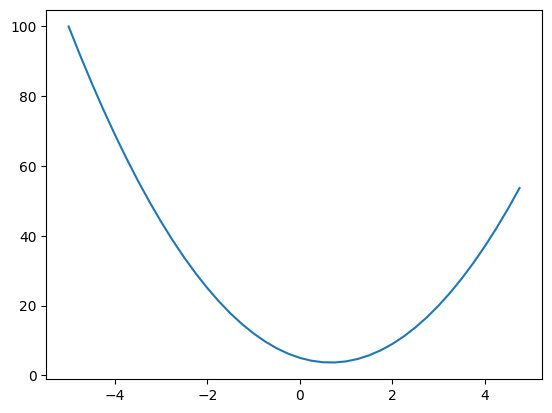

In [6]:
plt.plot(xs, f(xs))

In [10]:
# Calculate derivative (rise over small run 'h')

h = 0.0000001 # adjust for precision (will zero out if overflow)
x = 3.0
(f(x + h) - f(x)) / h # approx. of slope (derivative)

14.000000305713911

In [11]:
# more complex exmaple

a = 2.0
b = -3.0
c = 10.0

d = a*b + c # f(x)
a += h # dx
d2 = a*b + c # f(x+h)

print('slope', (d2-d)/h) # partial derivative

slope -2.9999999995311555


Intuitively doing calculus on the equation by hand,
partial derivative with respect to
- `a` = `b`
- `b` = `a`
- `c` = 1

You can verify by changing `a += h` to another variable.

## Value class

In [62]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._backward = lambda: None # leaf node there is nothing to do
        self._op = _op
        self.label = label
        self.grad = 0.0
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other): # add two Value objects
        out = Value(self.data + other.data, (self, other), '+')

        
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        return out
    
    def backward(self, ):
        # compute gradient?

        
        # backpropagate
        for child in self._prev():
            pass
        pass

    
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label='L'
# d = a*b + c
L

Value(data=-8.0)

In [46]:
# need to record previous children values in forward pass
# for backpropagation
d._prev, d._op

({Value(data=-6.0), Value(data=10.0)}, '+')

In [47]:
! pip install graphviz

In [63]:
# visualize parameter DAG
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

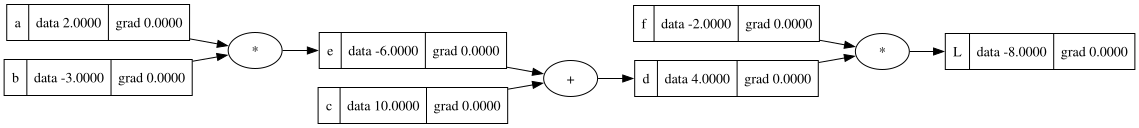

In [60]:
draw_dot(L) # visualization of forward and backward pass

# Manual Backpropagation

- dL/dL = 1 (self derivative)

### Local Derivative: 
L = d*f  
dL/df = d (4.0)  
dL/dd = f (-2.0)  

## Chain rule:

### "+" case: 

dL/dc = dL/dd (local) * dd/dc (prev.)

- dL/dc = change in L with respect to c

- dL/dd was previously computed (recursive backpropogation)
- dd/dc is "local derivative" used for future computations in backward pass (this is 1)

In our example, `d = c + e`. Essentially, a "+" operator just routes the gradient to children nodes. It passes it along with no changes. Since, "local derivative" of a "bias" will be 1.

Therefore, dL/de = -2.0.

### "*" case

e = a * b  
de/da = b (-3.0)  
dL/de = -2.0 (prev. gradient)  

dL/da = dL/de * de/da = -2.0 * -3.0 = 6!

### TLDR

**In backpropagation, we recursively compute partial derivatives thru chain rule, by multiplying the "local derivative" * "the previously computed one"!**

In [57]:
# estimating gradient (partial derivative)

# L = (a*b + c) * f
h = 0.0000001
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label='L'


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
d.data += h # partial derivative with respect to 'd'
f = Value(-2.0, label='f')
L2 = d*f; L2.label='L2'

slope = (L2.data - L.data) / h
slope

-2.0000000056086265

### Neuron Example

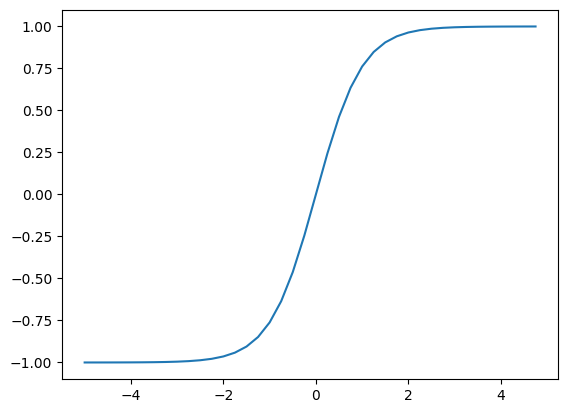

In [66]:
xs = np.arange(-5, 5, 0.25)
plt.plot(xs, np.tanh(xs))

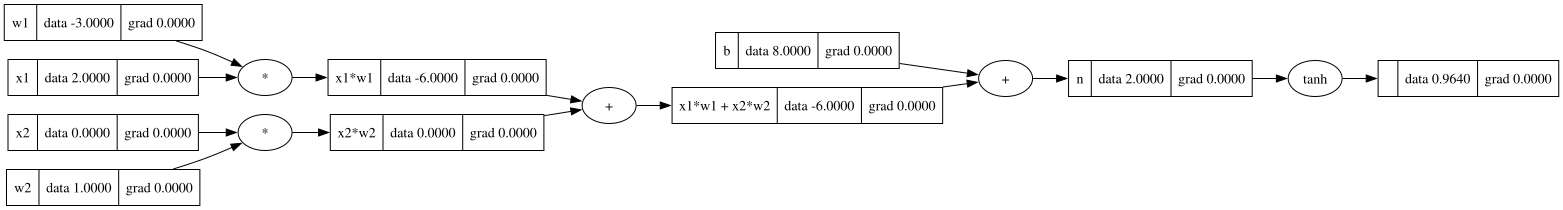

In [120]:

# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(8.0, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh()
draw_dot(o)


## Backpropagation Implementation

General Intuition:
1. Forward pass sets the "function" for the ***next*** node used for calculating the local derivative of the current node. This is dependent on the operation (+ or *) the node is involved in.
2. Backward pass calls this "backward function" to recursively pass gradients from output to input

Hence, forward pass and backpropagation go hand-in-hand.

In [146]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._backward = lambda: None # leaf node there is nothing to do
        self._op = _op
        self.label = label
        self.grad = 0.0
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __radd__(self, other):
        return self + other
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)

        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1 * out.grad
            other.grad += 1 * out.grad
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)

        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad # local grad * prev. grad (post-synaptic)
            other.grad += self.data * out.grad
        
        # set the gradient function for the next node
        # but updates the gradient of this current node
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other

    def backward(self): # runs once and recursively calls all _backwards calls

        # topological sort 
        # to get graph traversal order to satisfy backprop dependencies
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for c in v._prev:
                    build_topo(c) # process children first
                topo.append(v) # then process current node

        # results in a dependency DAG for output o
        build_topo(self)

        self.grad = 1.0 # set root as 1.0 as base case
        for node in reversed(topo):
            node._backward()
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int and float powers"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += (other)*self.data**(other-1) * out.grad
        out._backward = _backward
        
        return out


    def __truediv__(self, other): # self  / other => self * 1/other => self * other^-1
        return self * other**-1

    def __neg__(self): # -self
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad # tanh derivative
        out._backward = _backward

        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad = math.exp(x) * out.grad
        
        out._backward = _backward
        return out

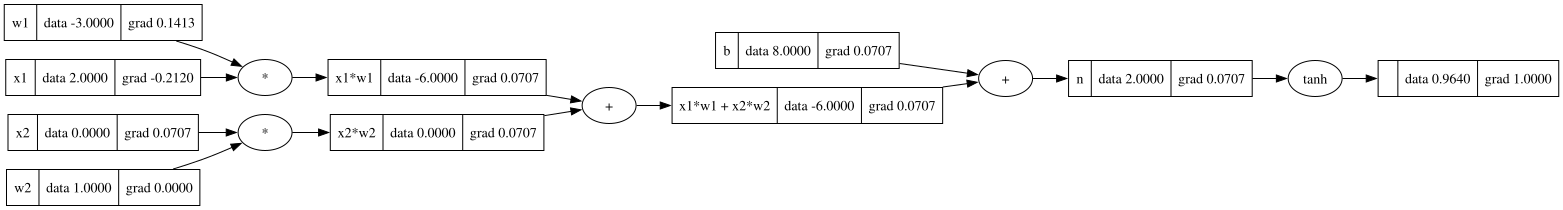

In [121]:
o.backward()
draw_dot(o)

### Same Value edge case

The local derivative is not the same in these two cases:
- x + x -> (dx/dL = 2)
- x + y -> (dx/dL = 1)

likewise for...

- x**2 -> (dx/dL = 2x)
- xy -> (dx/dL = y)

To account for this, we acumulate the gradients any value would have (i.e. we get the gradient of one "x" and add to the other "x")

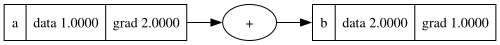

In [ ]:
a = Value(1.0, label='a')
b = a + a # adding two of the same value
b.label = 'b'
b.backward()
draw_dot(b)
# db/da = 2

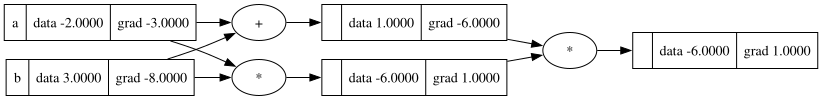

In [125]:
# also works for case where same value has more than one upstream value

a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b
e = a + b
f = d * e
f.backward()
draw_dot(f)

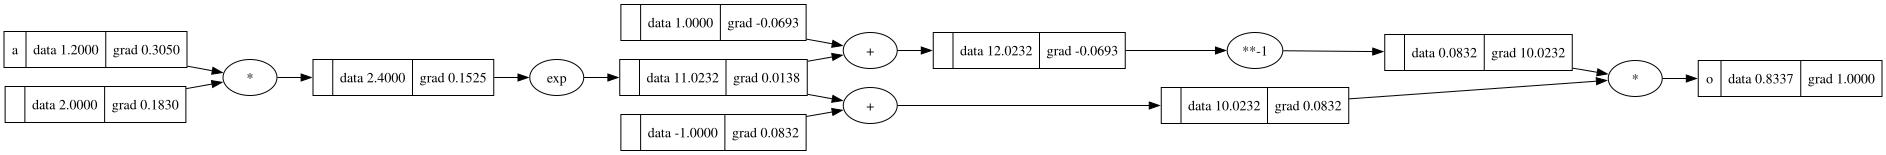

In [133]:
# tanh
a = Value(1.2, label='a')
b = (2*a).exp()
o = (b - 1) / (b + 1); o.label ='o'
o.backward()
draw_dot(o)

### PyTorch example

In [137]:
import torch

x1 = torch.Tensor([2.0]).double()      ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()      ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()     ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()      ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('—')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
—
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


## Neuron Class

In [161]:
import random
class Neuron:
    """
    One neuron "node"
    """
    def __init__(self, num_inputs):
        self.w = [Value(random.uniform(-1,1)) for _ in range(num_inputs)]
        self.b = Value(random.uniform(-1,1))
    
    def __call__(self, x):
        # w * x + b

        # linear combo
        activation = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        
        # non-linearity
        out = activation.tanh()

        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    """
    Process a layer of neurons
    """
    def __init__(self, num_inputs, num_outputs):
        self.neurons = [Neuron(num_inputs) for _ in range(num_outputs)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extend(ps)
        # return params

class MLP:
    """
    Process layers in MLP

    num_inputs - size of input layer
    num_outputs - list of layer hidden dims after input layer
    """

    def __init__(self, num_inputs: int, num_outputs: list):
        size = [num_inputs] + num_outputs
        self.layers = [Layer(size[i], size[i+1]) for i in range(len(num_outputs))]

    def __call__(self, x):
        for l in self.layers:
            x = l(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

Value(data=0.9206316008856297)

### Sample Training Dataset

In [151]:

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets
ypred = [n(x) for x in xs]
ypred


[Value(data=-0.8903382229617599),
 Value(data=0.30394829150664165),
 Value(data=0.4460828054931872),
 Value(data=-0.7111230780074056)]

In [155]:
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=10.2927574125459)

In [156]:
loss.backward()

In [159]:
# postive gradient = increasing weight will increase loss
# negative gradient = increasing weight will decrease loss
n.layers[0].neurons[0].w[0].grad

1.291211897351039

## Gradient Descent

In [167]:
# new weight = weight - (step_size * gradient)
# go in opposite direction of gradient to minimize loss

# GD steps
# 1. Forward pass and get Loss
# 2. Reset/zero out gradient
# 3. Calculate gradient
# 4. Backpropagate and update weights

step_size = -0.01
epochs = 20

for k in range(epochs):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])

    # backward pass
    for p in n.parameters(): # zero out the gradients before recomputing them
        p.grad = 0
    loss.backward() # compute gradient

    # update 
    for p in n.parameters():
        p.data += step_size * p.grad
    
    print(k, loss.data)

0 5.429184606265098e-07
1 5.429182363873815e-07
2 5.429180121484575e-07
3 5.429177879096953e-07
4 5.429175636710219e-07
5 5.429173394325531e-07
6 5.429171151943309e-07
7 5.429168909563132e-07
8 5.429166667185421e-07
9 5.429164424807749e-07
10 5.429162182435706e-07
11 5.429159940060966e-07
12 5.429157697689423e-07
13 5.42915545531962e-07
14 5.429153212954168e-07
15 5.429150970584865e-07
16 5.429148728221922e-07
17 5.429146485858712e-07
18 5.429144243501859e-07
19 5.429142001142735e-07


In [168]:
ypred

[Value(data=0.9999998788819636),
 Value(data=-0.9998086151899922),
 Value(data=-0.999288462262877),
 Value(data=0.9999997023543831)]